# Ising formulations of many NP problems
<a id="ref-lucas"></a>
[Lucas 2014] Lucas, A. *Ising formulations of many NP problems*. 
Frontiers in Physics, 2 (2014). [arXiv:1302.5843](https://arxiv.org/abs/1302.5843)

# Imports



In [51]:
import numpy as np
import scipy
import math
import random

from itertools import product # for generating all possible states of x


import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation # makes the animarion
from matplotlib.animation import PillowWriter #.gif writer

from IPython.display import HTML,display # display in nb

import networkx as nx # graphs

from numba import njit #optimization


# Spin glass annealing
Importing the code _spinglass.ipynb_ from 

In [14]:
def energy(s, J, h):
    # s is a flat 1D array of spins
    # J is (n, n) matrix
    # h is (n) vector
    return 0.5 * s @ J @ s - h @ s

@njit
def sweep_once(s, J, h, T, E):
    n=len(s)
    for _ in range(n):
        i = np.random.randint(n)
        
        dE = 2 * s[i] * (J[i] @s + h[i])        

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[i] *= -1
            E += dE

    return E

def sim_annealing(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy()


# Partitioning Problems
These partitioning problems are based off _spinglass.ipynb_  where we have a spin glass model.

$H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

 We will need to swap the general ising model build function `make_2d_ising(N,J_scalar,h_scalar)` to a function that has our problems ising structure. Building Q based off the energy cost function is our goal here.

## Number Partitioning 
Given a set of $N$ positive numbers $S=\{n_1,\cdots ,n_N\}$, is there a partition of numbers into two disjoint sets such that $R$ and $S-R$ have equal sums of their elements?

Our cost function will be,

$H=-A\left(\sum_i^Nn_is_i\right)^2=$

$\underbrace{-A\sum_{i=j}^Nn_i^2}_\text{constant}-2A\sum_{i<j}^Nn_in_js_is_j$

we can drop the constant in our optimization.

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

$J_{ij}=-An_in_j$

$h_i=0$

In [ ]:
def make_partition_ising_slower(n,A=1.0):
    n = np.asarray(n, dtype=np.float64)
    N=len(n)
    J = np.zeros((N,N))
    
    for i in range(N):
        for j in range(i+1,N):
            J[i,j] = -A * n[i] * n[j]
            J[j,i] = J[i,j]
    
    h = np.zeros(N)
    
    return J, h
    
def make_partition_ising(n, A=1.0):
    n = np.asarray(n, dtype=np.float64)

    J = -2 * A * np.outer(n, n)
    np.fill_diagonal(J, 0.0)

    h = np.zeros(len(n))

    return J, h

This structure defines ouf Q interaction matrix.

In [ ]:
numbers = np.array([3,1,1,2,2,1])

J, h = make_partition_ising(numbers)

temps, energies, spins = sim_annealing(
    J, h,
    T_start=10,
    T_end=0.01,
    alpha=0.99,
    sweeps_per_T=100
)

setA = numbers[spins == 1]
setB = numbers[spins == -1]

print("Set A:", setA, "sum =", np.sum(setA))
print("Set B:", setB, "sum =", np.sum(setB))
print("Difference =", abs(np.sum(setA) - np.sum(setB)))

Defining a function for this problem

In [ ]:
def run_partition_example(numbers,sweeps):
    print("Inputed numbers:", numbers)

    J, h = make_partition_ising(numbers)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    setA = numbers[spins == 1]
    setB = numbers[spins == -1]

    print("Set A:", setA, "sum =", np.sum(setA))
    print("Set B:", setB, "sum =", np.sum(setB))
    print("Difference =", abs(np.sum(setA) - np.sum(setB)))

We can try it for a random $n_i=rand$ for $S=\{n_1,\cdots ,n_N\}$

In [7]:
for _ in range(5):
    random_numbers = np.random.randint(1, 100, size=20)
    print(run_partition_example(random_numbers, 1000))

Set A: [93 82 81 84 10 11 32 83 90] sum = 566
Set B: [96 66 48 36 41 50 24 19 65 90 22] sum = 557
Difference = 9
None
Inputed numbers: [66 68 47 13 97 51 90 48 39 25 50 42 27 41 84 14 60 47 85 58]
Set A: [66 68 47 90 25 42 27 14 60 85] sum = 524
Set B: [13 97 51 48 39 50 41 84 47 58] sum = 528
Difference = 4
None


It solves our problem to the best of its ability, minimising the distance between two sets.

## Graph Partitioning

Given some undirected graph $G(V,E)$, where $v\in v$ are vertices and $e\in E$ are edges, we take a graph with and even number of edges $N=|V|$. The optimisation problem, what is the partition of V into two subsets that minimises the number of edges connecting the two subsets?

$ H=H_A+H_B$

$=A\left(\sum_i^Ns_i\right)^2+B\sum_{(i,j)\in E}\frac{1-s_is_j}{2}$

$=\underbrace{AN} _{\text{constant}}+\underbrace{\frac{B|E|}{2}}_{\text{constant}}+2A\sum_{i>j}^ Ns_is_j -\frac{B}{2}\sum_{(i,j)\in E}  s_is_j$

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$. 

$J_{ij}=\begin{cases}
        -2A ~~~~~~~~~\text{if }~(i,j)\notin E\\
        -2A -\frac{B}{2}~~~\text{if }~(i,j)\in E
    \end{cases}$

$h_i=0$

There exists a constraint on $A$ and $B$,

$\frac{A}{B}\geq\frac{\min(2\Delta,N)}{8}$ where $\Delta=\text{degree of } G$

In [23]:
nodes = ['a', 'b', 'c', 'd']
#     idx 0    1    2    3
idx = {v: i for i, v in enumerate(nodes)}

print(nodes)
print(idx)

# idx swaps label and index of nodes in a graph

['a', 'b', 'c', 'd']
{'a': 0, 'b': 1, 'c': 2, 'd': 3}


In [24]:
def make_graph_partition(G, A, B):
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    
    J = -2.0 * A * np.ones((N, N))
    np.fill_diagonal(J, 0.0)
    
    #
    idx = {v:i for i,v in enumerate(nodes)}
    
    for u,v in G.edges():
        i, j = idx[u], idx[v]
        J[i,j] += B/2.0
        J[j,i] += B/2.0
    
    h = np.zeros(N)
    return J, h

def decode_partition_solution(G, s):
    nodes = list(G.nodes())
    
    setA = [nodes[i] for i in range(len(s)) if s[i] == 1]
    setB = [nodes[i] for i in range(len(s)) if s[i] == -1]
    
    cut_edges = [(u,v) for u,v in G.edges() if (u in setA) != (v in setA)]
    
    print ("Set A:", setA , "size =", len(setA))
    print ("Set B:", setB , "size =", len(setB))
    print ("Cut edges:", cut_edges , "size =", len(cut_edges))
    
    return setA, setB, cut_edges

def check_valid_AB(A,B,G):
    N=G.number_of_nodes()
    delta=max(d for _,d in G.degree()) # max degree of graph
    rhs=min(2*delta, N)/8 
    lhs= A / B
    valid = lhs >= rhs
    print(f"Max degree Δ={delta},  bound A/|B| >= {rhs:.3f}")
    print(f"Current A/|B| = {lhs:.3f}  {'valid' if valid else 'INVALID'}")
    
    return valid

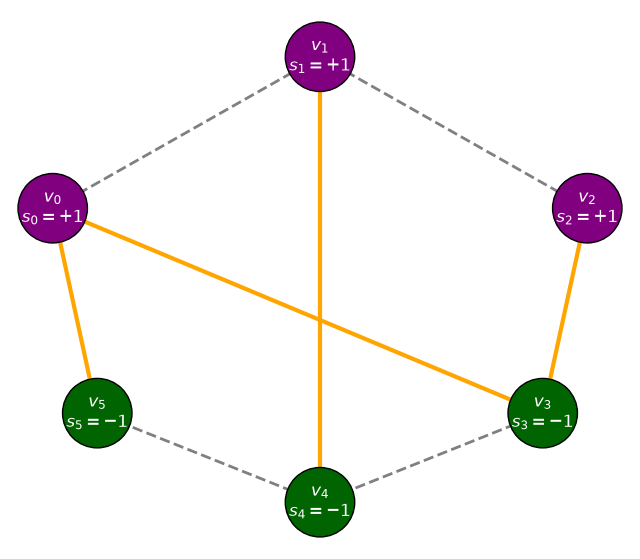

In [25]:
# Cycle graph C6 plus two connections
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

# positions for nodes in the graph for plotting to match my layout in Tikz
pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}

# worst spin configuration
spins = np.array([1, 1, 1, -1, -1, -1])

# Colour nodes
node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

# Separate cut and internal edges
cut_edges = []
internal_edges = []

for u, v in G.edges():
    if spins[u] != spins[v]:
        cut_edges.append((u, v))
    else:
        internal_edges.append((u, v))

plt.figure(figsize=(8,7))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=2500,
    edgecolors='black'
)

# Labels
labels = {i: f"$v_{i}$\n$s_{{{i}}}={spins[i]:+d}$" for i in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_color='white')

# Internal edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=internal_edges,
    edge_color='gray',
    style='dashed',
    width=2
)

# Cut edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=cut_edges,
    edge_color='orange',
    width=3
)

plt.axis('off')
plt.axis('equal')
plt.show()

We can make a plotting function without defining postions using `pos = nx.spring_layout(G, seed=13)` with a seed for reproducibility. Instead of inputing

`pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}`

We'll also make a spin-less/empty node graph function

In [26]:
def draw_empty_graph(G):
    pos = nx.spring_layout(G, seed=13)  

    n = G.number_of_nodes()
    
    node_colors = 'purple'

    all_edges = []

    for u, v in G.edges():
        all_edges.append((u, v))

    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {i: f"$v_{i}$" for i in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=all_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

And one with the cut edges defined once we input a spin.

In [27]:
def draw_graph_partition(G, spins):
    pos = nx.spring_layout(G, seed=13)  
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    n = G.number_of_nodes()
    
    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {}

    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=internal_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    # Cut edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=cut_edges,
        edge_color='orange',
        width=3
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

In [28]:
def run_partition_graph_example(G, A, B, sweeps):
    print("Inputed graph:")
    draw_empty_graph(G)
    
    print(f"A={A}, B={B}")
    check_valid_AB(A, B, G)

    J, h = make_graph_partition(G, A, B)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    #setA, setB, cut_edges = decode_partition_solution(G, spins)
    
    draw_graph_partition(G, spins)

Inputed graph:


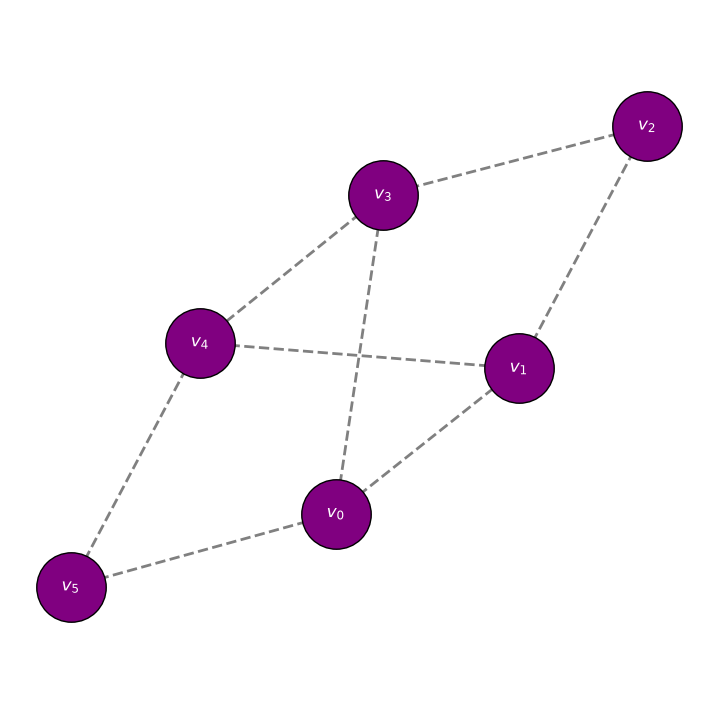

A=4, B=2
Max degree Δ=3,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


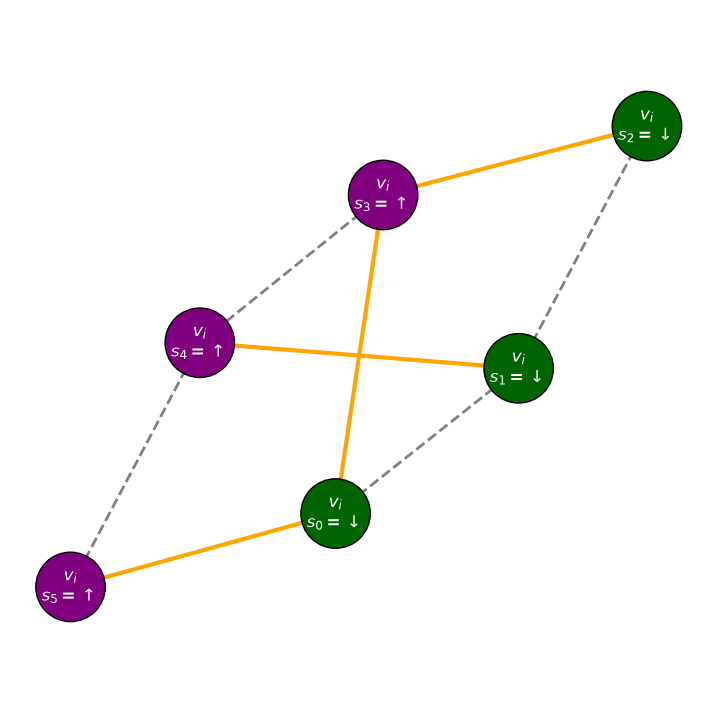

In [29]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

run_partition_graph_example(G, A=4, B=2, sweeps=1000)

That is solving the problem to minimise the cut edes, now we can try it with random $G(E,V)$

In [30]:
def run_random_partition_graph_example(lower, upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")

    run_partition_graph_example(G, A=4, B=2, sweeps=1000)

n = 8
Added 2 extra edges
Inputed graph:


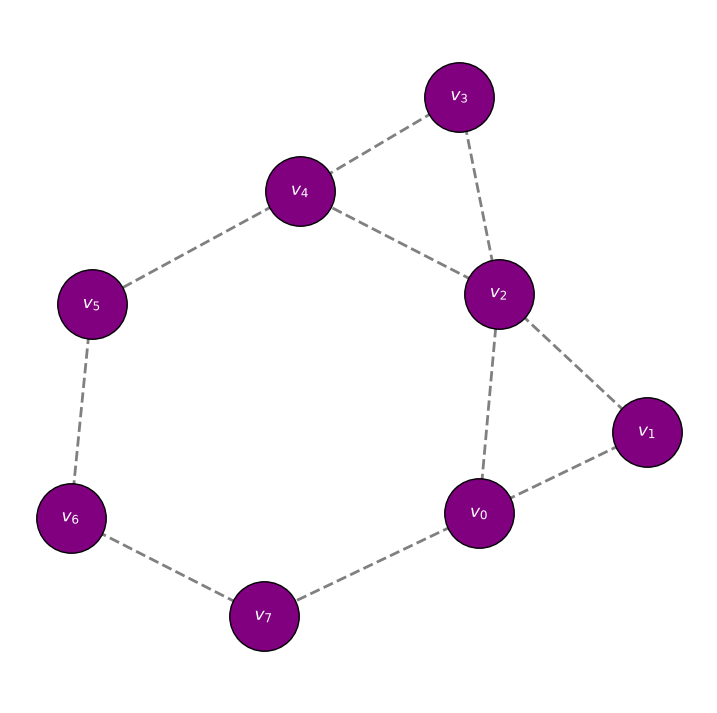

A=4, B=2
Max degree Δ=4,  bound A/|B| >= 1.000
Current A/|B| = 2.000  valid


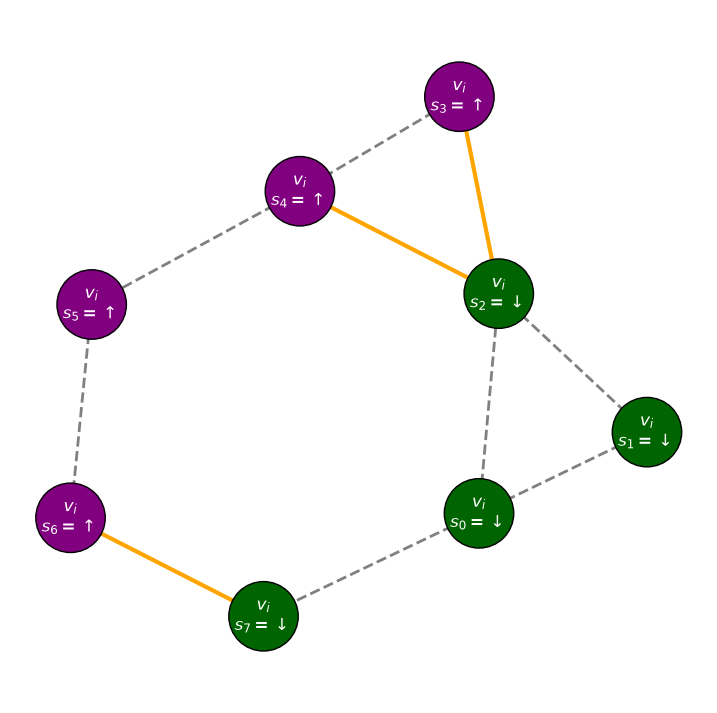

In [31]:
run_random_partition_graph_example(6, 100)

#### Animation

I think it'd be fun to plot the annealing process. We need to save the spin history in the annealing, then update our spins diagrams.

Redefining the annealing,



In [32]:
def sim_annealing_animation(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    history = []
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        history.append(s.copy())
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy(), history

In [33]:
def update(frame):
    
    ax.clear()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    
    spins = history[frame]
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=1900,
        edgecolors='black',
        ax=ax
    )
    
    # Labels
    labels = {}
    
    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_color="white",
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=internal_edges,
        edge_color="gray",
        style="dashed",
        width=2,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cut_edges,
        edge_color="orange",
        width=3,
        ax=ax,
    )
    
    ax.set_title(
        f"Step {frame} | "
        f"T = {temps[frame]:.3f} | "
        f"E = {energies[frame]:.2f}",
        fontsize=16
    )
    
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    

In [38]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

def run_partition_graph_animation(G):
    pos = nx.spring_layout(G, seed=13)

    # fix the axis limits to avoid rescaling during the animation
    x_values = [p[0] for p in pos.values()]
    y_values = [p[1] for p in pos.values()]

    margin = 0.5

    xlim = (min(x_values)-margin, max(x_values)+margin)
    ylim = (min(y_values)-margin, max(y_values)+margin)

    n = G.number_of_nodes()
    size = max(9, 0.8 * n)

    fig, ax = plt.subplots(figsize=(size, size))

    J, h = make_graph_partition(G, A=4, B=4)
    temps, energies, spins, history = sim_annealing_animation(
        J,
        h,
        T_start=10,
        T_end=0.1,
        alpha=0.99,
        sweeps_per_T=1000
        )

    history = history[::2]  # downsample the history for faster animation
    energies = energies[::2]  # downsample the energies for faster animation
    temps = temps[::2]  # downsample the temperatures for faster animation
    spins = spins[::2]  # downsample the spins for faster animation

    def update(frame):
        
        ax.clear()
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        
        spins = history[frame]
        
        # Colour nodes
        node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

        # Separate cut and internal edges
        cut_edges = []
        internal_edges = []

        for u, v in G.edges():
            if spins[u] != spins[v]:
                cut_edges.append((u, v))
            else:
                internal_edges.append((u, v))

        # Nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color=node_colors,
            node_size=1900,
            edgecolors='black',
            ax=ax
        )
        
        # Labels
        labels = {}
        
        for i in G.nodes:
            arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
            labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
        
        nx.draw_networkx_labels(
            G,
            pos,
            labels,
            font_color="white",
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=internal_edges,
            edge_color="gray",
            style="dashed",
            width=2,
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=cut_edges,
            edge_color="orange",
            width=3,
            ax=ax,
        )
        
        ax.set_title(
            f"Step {frame} | "
            f"T = {temps[frame]:.3f} | "
            f"E = {energies[frame]:.2f}",
            fontsize=16
        )
        
        ax.set_axis_off()
        ax.set_aspect("equal")
    
    
    
    animation = FuncAnimation(fig, update, frames=len(history), interval=500, repeat=False)
    
    return animation

In [35]:
# display the animation in the notebook
# display(HTML(animation.to_jshtml()))

# download the animation as a GIF
'''
animation.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)
'''

'\nanimation.save(\n    "annealing.gif",\n    writer=PillowWriter(fps=10)\n)\n'

In [36]:
def run_random_partition_graph_animation(lower, upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")

    anim_random = run_partition_graph_animation(G)
    
    return anim_random

n = 16
Added 6 extra edges


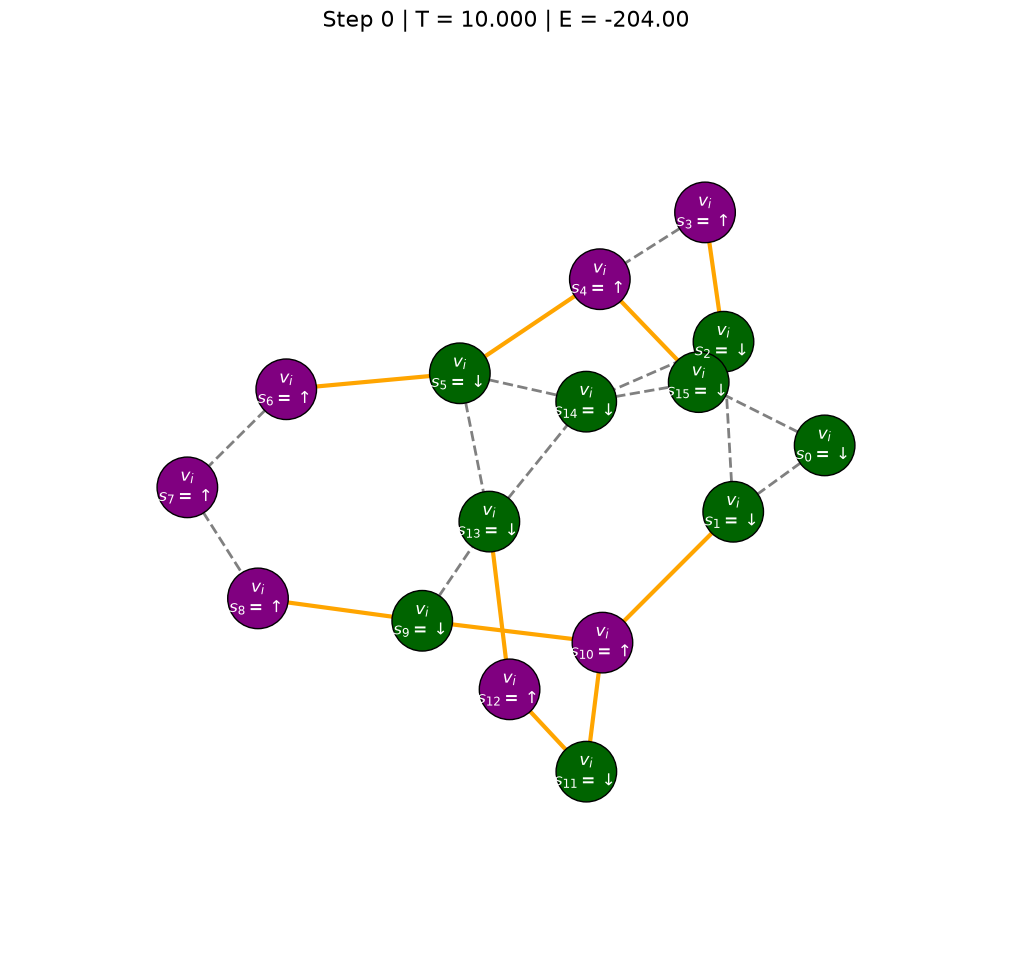

In [39]:
anim = run_random_partition_graph_animation(10, 35)
anim.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)

These seem to work, they're a nice display of the annealing process.

# QUBO annealing
Importing the solving functions from`QUBO-anneal.pynb`, this is less optimised than my ising model code. All we've done is redefine the energy function and sweeping functions.

In [158]:
@njit
def energy_QUBO(x, Q):
    return x @ Q @ x

@njit
def sweep_once_QUBO(x, Q, T, E):
    N = len(x)
    for _ in range(N):
        i = np.random.randint(N) 

        old_bit = x[i]
        x[i] = 1 - x[i]  # Flip the binary spin (0 to 1 or 1 to 0)
        
        # Calculate the change in energy if we flip spin i
        new_E = energy_QUBO(x, Q)
        delta_E = new_E - E
        
        # Metropolis criterion
        if delta_E < 0 or np.random.rand() < np.exp(-delta_E / T):
            E = new_E  # Accept the new configuration
        else:
            x[i] = old_bit  # Revert the flip if not accepted  
            
    return E

def sim_annealing(Q, T_start, T_end, alpha, sweeps_per_T):
    n = Q.shape[0]
    x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)

    E = energy_QUBO(x, Q)

    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once_QUBO(x, Q, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), x.copy()

We also have a small brute force checker to compare to our annealing results, I believe its only feasable for 2-4 Qs.

In [159]:
def brute_force_qubo(Q):
    n = Q.shape[0]

    best_energy = np.inf # set  to infiniy  
    best_x = None

    for x in product([0, 1], repeat=n): #produce generate all possible binary configurations of length n
        x = np.array(x, dtype=np.int8)
        E = x @ Q @ x

        if E < best_energy:
            best_energy = E
            best_x = x.copy()

    return best_energy, best_x

# Binary Integer Linear Programming (BILP)

This class of problems is the next jump, we define the problem.

We have N binary variables $\vec x\in\{0,1\}^N$ which we want to arange into a vector $\vec x$ such that we maximise $\vec c \cdot \vec x$, given the restraint $S \vec x = \vec b$.

Where $S$ is a $m\times N$ matrix and $\vec b \in$ is a vector with m components.



Now taking a classic ILP problem is defined like,

$\underset{x,y \in \mathbb{Z}}{\text{maximize}} \quad  y$
subject to 
$\quad -x +y \leq 1, 3x + 2y \leq 12, 2x + 3y \leq 12, x,y \ge 0$


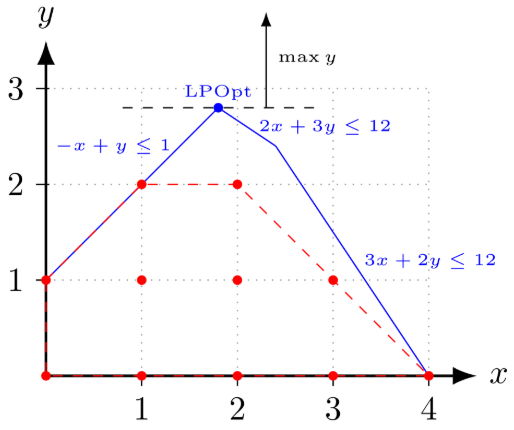

This is is a nice way of visulising our solution, however for our binary version there is no interior.

Now take some vector $\vec x=\begin{pmatrix}x_1\\x_2\\x_3\end{pmatrix}$ 

where $x_i\in\{0,1\}$ so our solutions are a cube with the corners being the solutions. So for N binary variables $\vec x\in\{0,1\}^N$ we have a  ***N*** *hyper-cube* for our solutions with no interior, so the classic ILP diagrams don't really help to visualise.


***Back to QUBO***

Now, we swap from ising formulation of $s=\begin{cases}1\\-1\end{cases}$ into a binary representation $x=\begin{cases}0\\1\end{cases}$

This can be done with the transformation, $x_i\rightarrow \frac{1+s_i}{2}$

Now like last time we will have two components to $H=H_A+H_B$

$H_A=A\sum_{j=1}^m\left(b_j-\sum_{i=1}^N S_{ji}x_i\right)^2$ this will enforce $S \vec x = \vec b$

&

$H_B = -B\sum_{i=1}^Nc_ix_i$ which will maximise $\vec c \cdot \vec x$


There exists conditions on $A$ and $B$ where $\frac{A}{B}\gtrsim N$

$H_A=\sum_{i=1}^N~\underbrace{A\sum_{j=1}^m(S_{ji}^2-2b_jS_{ji})}_{h_i}x_i+ \sum_{i<k}^N~\underbrace{2A\sum_{j=1}^mS_{ji}S_{jk}}_{J_{ij}}x_ix_k$

$H_B =\sum_{i=1}^N\underbrace{-Bc_i}_{h_i}x_i$

$Q_{ii}=A\sum_{j=1}^m(S_{ji}^2-2b_jS_{ji}) -Bc_i$

and

$Q_{ij}=2A\sum_{j=1}^mS_{ji}S_{jk}$

here we've swapped to $Q_{ij}$ instead of $J_{ij}$ since we have binary inputs rather than spins.

In [85]:
def make_BILP(S,b,c, A, B):
    # S is  mxn matrix of coefficients for constraints
    # b is m vector of constants for constraints
    # c is n vector of coefficients for the objective function
    
    m, N = S.shape
    Q = np.zeros((N, N))
    
    #diagonal terms  
    for i in range(N):
        Q[i,i] += A * np.sum(S[:,i]**2 - 2*b*S[:,i])  - B * c[i]
    
    # off-diagonal terms
    for i in range(N):
        for j in range(i+1, N):
            Q[i,j] += 2 * A * np.sum(S[:,i] * S[:,j])
            Q[j,i] = Q[i,j]
            
    return Q

def read_BILP(x, c, S, b, verbose):
    # x is a binary vector of length N
    # c is a vector of length N
    # S is a mxN matrix of coefficients for constraints
    # b is a vector of length m

    objective_value = c @ x
    constraint_values = S @ x
    residuals = constraint_values - b
    feasible = np.allclose(residuals, 0)
   
    print(f"x = {x.astype(int)}")
    
    if verbose:
    
        print(f"Objective value c·x = {objective_value}")
        #print(f"Constraint values Sx = {constraint_values}")
        print(f"Residuals Sx - b = {residuals}  (should be 0)")
        print(f"Feasible: {feasible}")

    return objective_value, constraint_values, residuals

In [86]:
def compare_brute_force_and_annealing(Q, S, b, c):
    Q = make_BILP(S, b, c, A, B)
    print("Q =\n", Q)
    # Brute force verify
    brute_E, brute_x = brute_force_qubo(Q)
    print("\nBrute force solution:")
    read_BILP(brute_x, c, S, b, False)
    #print(f"Brute force energy: {brute_E}")

    # Simulated annealing
    temps, energies, x_anneal = sim_annealing(
        Q, 
        T_start=10.0, 
        T_end=0.01,
        alpha=0.95, 
        sweeps_per_T=1000
    )
    
    print("\nSimulated annealing solution:")
    read_BILP(x_anneal, c, S, b, False)
    #print(f"Annealing energy: {w}")
    
    def_x = brute_x - x_anneal
    same = np.allclose(def_x, 0)
    print(f"\nThe brute force and annealing are the same: {same}")

In [87]:
S = np.array([[1, 1, 1]], dtype=float)   # x1 + x2 + x3 = 1
b = np.array([1,0])
c = np.array([3.0, 1.0, 2.0])           # maximise 3x1 + x2 + 2x3

A=2.0
B=1.0

compare_brute_force_and_annealing(Q, S, b, c)


Q =
 [[-3.  4.  4.]
 [ 4. -1.  4.]
 [ 4.  4. -2.]]

Brute force solution:
x = [1 0 0]

Simulated annealing solution:
x = [1 0 0]

The brute force and annealing are the same: True


In [157]:
def random_BILP(m, N, seed=None,repeat=3):
    # instead of np.random reproducable
    rng = np.random.default_rng(seed)

    # Random feasible binary solution
    x_true = rng.integers(0, 2, size=N)
    
    print("x true", x_true)
    
    # Random constraint matrix
    S = rng.integers(-2, 3, size=(m, N)).astype(float)

    # Compute b so x_true is feasible
    b = S @ x_true

    # Random objective
    c = rng.integers(-5, 6, size=N).astype(float)

    A = 10 * np.sum(np.abs(c)) / np.min(np.sum(np.abs(S), axis=1))
    B = 1

    Q = make_BILP(S, b, c, A=A, B=B)
    
    print("Our Q matrix:")
    print (Q)
    
    print("x_true:", x_true)
    print("Feasible?", np.allclose(S @ x_true, b))
    print("Objective:", c @ x_true)
    
    for i in range(repeat):
        temps, energies, x_anneal = sim_annealing(
            Q, 
            T_start=20.0, 
            T_end=1e-4,
            alpha=0.99, 
            sweeps_per_T=sweeps
        )
        
        print("\nSimulated annealing solution:", {i+1})
        read_BILP(x_anneal, c, S, b, True)
        #print("x:", x_anneal[:N])
        #print("Constraint residual:", S @ x_anneal[:N] - b)
        print("Objective:", c @ x_anneal[:N])

'''
for j in range(2,4,4):
    print("\n===== N =", j, "=====")
    sweeps = 2000 * j
    random_BILP(j, j, seed=42)
'''

'\nfor j in range(2,4,4):\n    print("\n===== N =", j, "=====")\n    sweeps = 2000 * j\n    random_BILP(j, j, seed=42)\n'

This last randomisation doesn't work, I believe its due to the values of $A$ and $B$, currently 

`A = 10 * np.sum(np.abs(c)) / np.min(np.sum(np.abs(S), axis=1))` `B=1`

doesn't seem to work.

We're going to move on cause BILP doesn't offer much more to our end goals.

# Graph Colouring

Lets take another undirected graph $G(V,E)$ and $n$ colours. Can we colour each vertex such that no edge connects vertices of the same colour? This is a generaliseation of the famous how many colours are needed to colour a map such that no two countries of the same colour share a border, ($n\geq 4$).

<a id="ref-appel1"></a>
[Appel and Haken 1977a] Appel, K. and Haken, W. *Every planar map is four colorable. I. Discharging*. Illinois Journal of Mathematics, **21**, 429–490 (1977).

<a id="ref-appel2"></a>
[Appel et al. 1977b] Appel, K., Haken, W., and Koch, J. *Every planar map is four colorable. II. Reducibility*. Illinois Journal of Mathematics, **21**, 491–567 (1977).

We introduce two index binary variables $x_{v,i}$ which will be one if vertex $v\in V$ has colour $i$ or its $0$.

We build a similar idea to previous examples with,

$H_{A,1}= A \sum_v\left(1-\sum_{i=1}^nx_{v,i}\right)$ 

which enforces that each index has one colour, penalising otherwise.

Then, 
$H_{A,2}= A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

adds a penalty for one colour $i$ connecting two vertices $u$ and $v$.

$H=A \sum_v\left(1-\sum_{i=1}^nx_{v,i}\right) +A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

In [ ]:
def build_graph_colour():
    